# Inflación: tendencia, mercado y pronósticos

Tres preguntas que la variación anual del INPC no contesta por sí sola:

1. **¿Hacia dónde va?** — medidas de tendencia que reaccionan antes que la anual.
2. **¿Qué espera el mercado?** — inflación implícita en los precios de Bonos M y Udibonos.
3. **¿Qué diría un modelo sencillo?** — pronósticos de referencia, evaluados fuera de muestra.

El token no aparece en el notebook: `siebanxico` lo toma del entorno (ver la documentación).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import siebanxico as sie

GUINDA, TEAL, OCRE, GRIS = '#800020', '#0F7173', '#C9A227', '#646464'
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'grid.color': '#EDEDED',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
                     'legend.frameon': False})

bmx = sie.Banxico()
INICIO = '2005-01-01'

## 1. ¿Hacia dónde va? Medidas de tendencia

La inflación anual compara con hace doce meses, así que arrastra lo que pasó hace un año. Tres
lecturas complementarias:

- **Subyacente**: excluye agropecuarios, energéticos y tarifas, que son volátiles.
- **Media truncada** (calculada por Banxico): descarta cada mes los genéricos con las variaciones
  más extremas, sean los que sean.
- **Impulso 3m/3m**: promedio de los últimos tres meses contra los tres previos, desestacionalizado
  y anualizado. Reacciona meses antes que la anual.

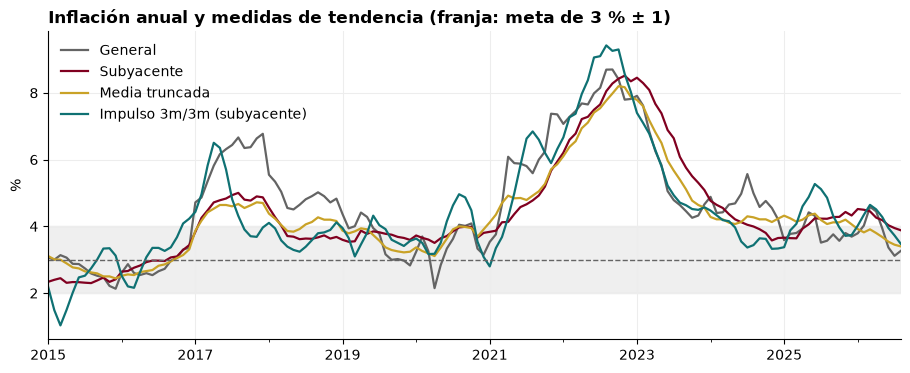

,General,Subyacente,Media truncada,Impulso 3m/3m (subyacente)
fecha,,,,
2026-03-01,4.59,4.45,3.91,4.64
2026-04-01,4.45,4.26,3.80,4.51
2026-05-01,3.94,4.19,3.68,4.28
2026-06-01,3.37,4.03,3.54,3.95
2026-07-01,3.12,3.95,3.45,3.73
2026-08-01,3.26,3.88,3.40,3.48


In [2]:
indices = bmx.descargar(['inpc', 'inpc_subyacente'], INICIO)
truncada = bmx.serie('media_truncada', INICIO)

tendencia = pd.DataFrame({
    'General'           : sie.variacion_anual(indices['inpc']),
    'Subyacente'        : sie.variacion_anual(indices['inpc_subyacente']),
    'Media truncada'    : truncada,
    'Impulso 3m/3m (subyacente)': sie.impulso(indices['inpc_subyacente'], 3),
}).loc['2015':]

ax = tendencia.plot(color=[GRIS, GUINDA, OCRE, TEAL], lw=1.6)
ax.axhspan(2, 4, color=GRIS, alpha=.10)
ax.axhline(3, color=GRIS, ls='--', lw=1)
ax.set_title('Inflación anual y medidas de tendencia (franja: meta de 3 % ± 1)')
ax.set_ylabel('%'); ax.set_xlabel('')
plt.show()

tendencia.dropna().tail(6).round(2)

### Persistencia

La suma de los coeficientes de un AR(12) sobre la inflación mensual desestacionalizada mide cuánto
tardan en disiparse los choques: cerca de 0 se revierten pronto, cerca de 1 se quedan. Estimada en
ventanas móviles de diez años muestra si la inflación se ha vuelto más o menos persistente.

Persistencia de la subyacente, muestra completa: 0.83


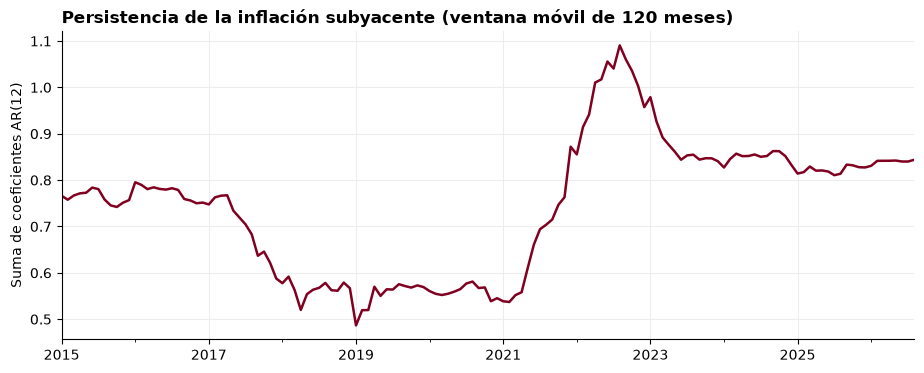

In [3]:
mensual_sa = sie.variacion(sie.desestacionalizar(indices['inpc_subyacente']))

print(f'Persistencia de la subyacente, muestra completa: {sie.persistencia(mensual_sa):.2f}')

ax = sie.persistencia(mensual_sa, ventana=120).plot(color=GUINDA, lw=1.8)
ax.set_title('Persistencia de la inflación subyacente (ventana móvil de 120 meses)')
ax.set_ylabel('Suma de coeficientes AR(12)'); ax.set_xlabel('')
plt.show()

## 2. ¿Qué espera el mercado? Inflación implícita

Un **Bono M** paga una tasa nominal; un **Udibono** paga una tasa real más la inflación observada.
La inflación que deja indiferente a un inversionista entre ambos es

$$\pi^{impl} = \frac{1 + i}{1 + r} - 1$$

Banxico publica cada día el precio, el cupón y los días por vencer de los títulos de referencia,
pero no su rendimiento. `bmx.inflacion_implicita` lo calcula con la convención mexicana (cupones
cada 182 días, base 360) y devuelve las dos tasas y su diferencia.

In [4]:
bei = bmx.inflacion_implicita(10, INICIO)
bei.tail(5).round(3)

,nominal,real,implicita,plazo_nominal,plazo_real
fecha,,,,,
2026-09-29,9.620,4.981,4.419,9.396,10.565
2026-09-30,9.608,5.050,4.339,9.394,10.563
2026-10-01,9.510,4.960,4.335,9.391,10.560
2026-10-02,9.530,4.910,4.404,9.388,10.557
2026-10-05,9.517,4.860,4.441,9.380,10.549


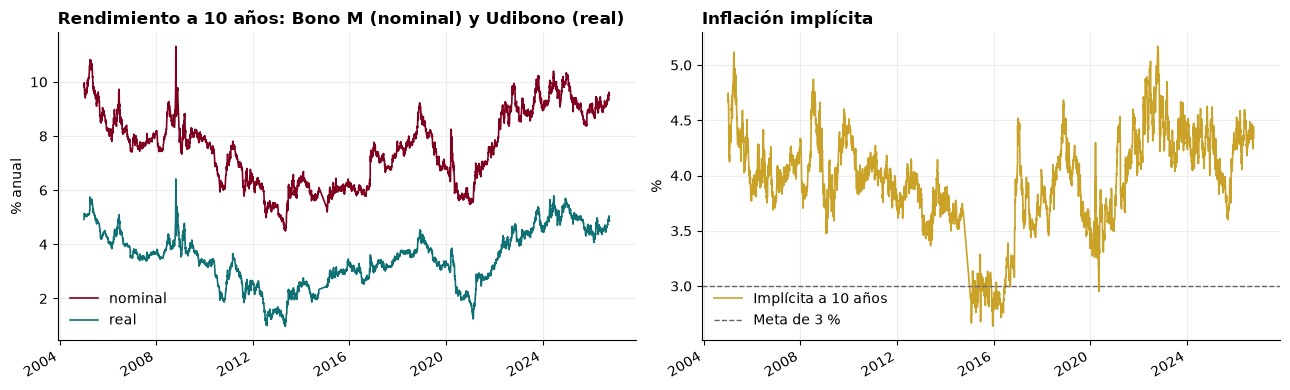

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

bei[['nominal', 'real']].plot(ax=ax[0], color=[GUINDA, TEAL], lw=1.2)
ax[0].set_title('Rendimiento a 10 años: Bono M (nominal) y Udibono (real)')
ax[0].set_ylabel('% anual'); ax[0].set_xlabel('')

bei['implicita'].plot(ax=ax[1], color=OCRE, lw=1.2, label='Implícita a 10 años')
ax[1].axhline(3, color=GRIS, ls='--', lw=1, label='Meta de 3 %')
ax[1].set_title('Inflación implícita')
ax[1].set_ylabel('%'); ax[1].set_xlabel(''); ax[1].legend()

plt.tight_layout(); plt.show()

### No es una expectativa pura

La implícita incluye una **prima por riesgo inflacionario** (la sube) y una **prima de liquidez** de
los Udibonos (la baja); Banxico la llama *compensación por inflación y riesgo inflacionario*. Además,
los dos títulos de referencia rara vez vencen el mismo día (columnas `plazo_nominal` y `plazo_real`),
y el vector de precios tiene meses sin datos y saltos cuando cambia el título de referencia.

Por eso conviene ponerla junto a lo que responden los especialistas en la encuesta de Banxico.

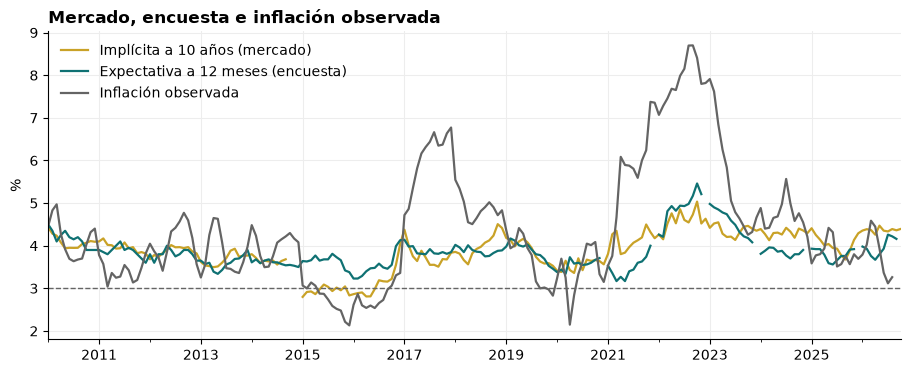

,Implícita a 10 años (mercado),Expectativa a 12 meses (encuesta),Inflación observada
fecha,,,
2026-05-01,4.47,3.80,3.94
2026-06-01,4.35,3.93,3.37
2026-07-01,4.34,4.26,3.12
2026-08-01,4.39,4.22,3.26


In [6]:
encuesta = bmx.serie('expectativa_inflacion_12m', INICIO)
observada = sie.variacion_anual(indices['inpc'])

comparacion = pd.DataFrame({
    'Implícita a 10 años (mercado)'  : sie.a_mensual(bei['implicita'], 'promedio'),
    'Expectativa a 12 meses (encuesta)': encuesta,
    'Inflación observada'            : observada,
}).loc['2010':]

ax = comparacion.plot(color=[OCRE, TEAL, GRIS], lw=1.6)
ax.axhline(3, color=GRIS, ls='--', lw=1)
ax.set_title('Mercado, encuesta e inflación observada')
ax.set_ylabel('%'); ax.set_xlabel('')
plt.show()

comparacion.dropna().tail(4).round(2)

### Curva de implícitas e implícita forward

Con varios plazos se obtiene la inflación que el mercado descuenta para un periodo **futuro**. La
de 10 años dentro de 10 años («10a10a») deja fuera los choques de corto plazo y es una lectura más
limpia del anclaje de largo plazo. Es una aproximación: supone que los títulos vencen exactamente a
10 y 20 años, y el Bono M del grupo «10 a 20 años» suele ser más corto.

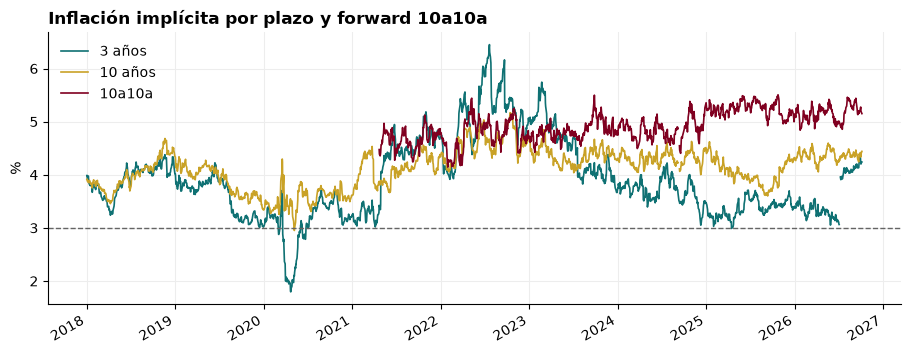

,3,10,20,30,10a10a
fecha,,,,,
2026-10-01,4.20,4.33,4.76,4.95,5.19
2026-10-02,4.22,4.40,4.79,4.97,5.19
2026-10-05,4.24,4.44,4.80,4.96,5.15


In [7]:
RECIENTE = '2018-01-01'
curva = pd.DataFrame({plazo: bmx.inflacion_implicita(plazo, RECIENTE)['implicita']
                      for plazo in (3, 10, 20, 30)})
curva['10a10a'] = sie.inflacion_implicita_forward(curva[10], curva[20], 10, 20)

ax = curva[[3, 10, '10a10a']].rename(columns={3: '3 años', 10: '10 años'}).plot(
    color=[TEAL, OCRE, GUINDA], lw=1.2)
ax.axhline(3, color=GRIS, ls='--', lw=1)
ax.set_title('Inflación implícita por plazo y forward 10a10a')
ax.set_ylabel('%'); ax.set_xlabel('')
plt.show()

curva.tail(3).round(2)

### Tasa real: ex-post, ex-ante y de mercado

Tres respuestas distintas a «¿cuál es la tasa real?»: descontando la inflación ya observada,
descontando la esperada, o leyendo directamente el rendimiento del Udibono.

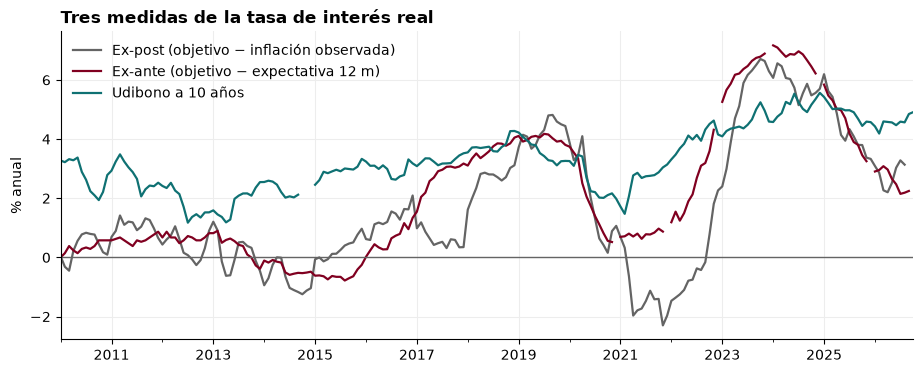

In [8]:
objetivo = sie.a_mensual(bmx.serie('tasa_objetivo', INICIO), 'promedio')

reales = pd.DataFrame({
    'Ex-post (objetivo − inflación observada)': sie.tasa_real(objetivo, observada),
    'Ex-ante (objetivo − expectativa 12 m)'   : sie.tasa_real(objetivo, encuesta),
    'Udibono a 10 años'                       : sie.a_mensual(bei['real'], 'promedio'),
}).loc['2010':]

ax = reales.plot(color=[GRIS, GUINDA, TEAL], lw=1.6)
ax.axhline(0, color=GRIS, lw=1)
ax.set_title('Tres medidas de la tasa de interés real')
ax.set_ylabel('% anual'); ax.set_xlabel('')
plt.show()

## 3. ¿Qué diría un modelo sencillo? Pronósticos de referencia

`pronosticar_inflacion` ajusta un SARIMA al logaritmo del INPC —por omisión el «modelo de
aerolíneas» $(0,1,1)(0,1,1)_{12}$— y simula trayectorias para obtener el intervalo de la inflación
**anual**, que depende de varios meses pronosticados a la vez.

In [9]:
inpc = indices['inpc'].dropna()
pronostico = sie.pronosticar_inflacion(inpc, horizonte=12, nivel=0.90)
pronostico.round(2)

,indice,mensual,anual,anual_inf,anual_sup
fecha,,,,,
2026-09-01,145.98,0.36,3.39,2.96,3.83
2026-10-01,146.73,0.51,3.55,2.84,4.29
2026-11-01,147.69,0.65,3.53,2.66,4.49
2026-12-01,148.34,0.44,3.70,2.64,4.83
2027-01-01,149.15,0.55,3.87,2.62,5.18
2027-02-01,149.76,0.41,3.78,2.41,5.24
2027-03-01,150.51,0.51,3.42,1.95,5.01
2027-04-01,150.69,0.12,3.34,1.80,4.97
2027-05-01,150.61,-0.05,3.50,1.85,5.29


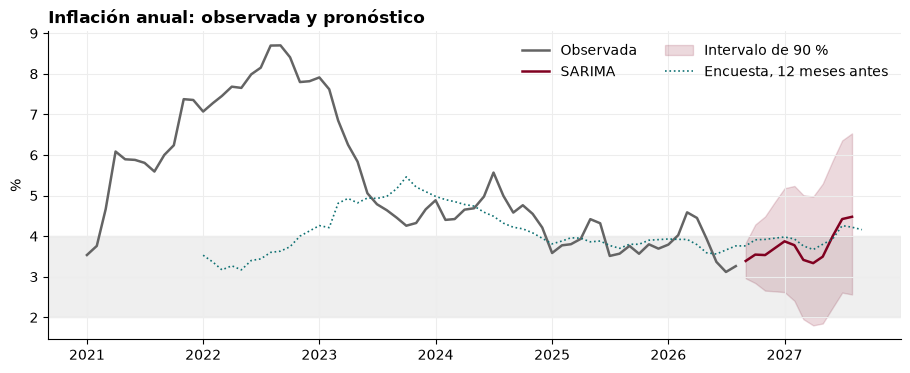

In [10]:
historia = sie.variacion_anual(inpc).loc['2021':]

fig, ax = plt.subplots()
ax.plot(historia, color=GRIS, lw=1.8, label='Observada')
ax.plot(pronostico['anual'], color=GUINDA, lw=1.8, label='SARIMA')
ax.fill_between(pronostico.index, pronostico['anual_inf'], pronostico['anual_sup'],
                color=GUINDA, alpha=.15, label='Intervalo de 90 %')
ax.plot(encuesta.loc['2021':].index + pd.DateOffset(months=12), encuesta.loc['2021':],
        color=TEAL, lw=1.2, ls=':', label='Encuesta, 12 meses antes')
ax.axhspan(2, 4, color=GRIS, alpha=.10)
ax.set_title('Inflación anual: observada y pronóstico')
ax.set_ylabel('%'); ax.legend(ncols=2)
plt.show()

### ¿Y sirve? Evaluación fuera de muestra

Un pronóstico solo vale lo que valió en el pasado. `evaluar_pronosticos` regresa en el tiempo,
estima el modelo **solo con lo que se conocía en cada fecha**, pronostica, y compara contra lo que
ocurrió. El rival es el método ingenuo: «la inflación anual se queda donde está».

In [11]:
evaluacion = sie.evaluar_pronosticos(inpc, horizontes=(1, 3, 6, 12), desde='2012-01-01', paso=3)
evaluacion['mejora_%'] = (1 - evaluacion['sarima'] / evaluacion['ingenuo']) * 100
evaluacion.round(3)

,sarima,ingenuo,n,mejora_%
horizonte,,,,
1,0.309,0.468,59,33.949
3,0.589,0.746,58,21.138
6,0.947,1.113,57,14.913
12,1.582,1.782,55,11.212


La tabla es la raíz del error cuadrático medio, en puntos porcentuales de inflación anual.
Dos lecturas honestas:

- El error **crece rápido con el horizonte**: a doce meses supera el punto porcentual, más que el
  ±1 del intervalo de variabilidad de Banxico.
- La ventaja sobre el método ingenuo es clara a un mes y **se diluye con el horizonte**. Es el
  resultado clásico de la literatura (Atkeson y Ohanian, 2001): a un año es difícil ganarle a
  «la inflación seguirá como está».

El intervalo del pronóstico solo refleja choques futuros bajo el modelo; no incluye la incertidumbre
de los parámetros ni la de haber elegido mal el modelo.

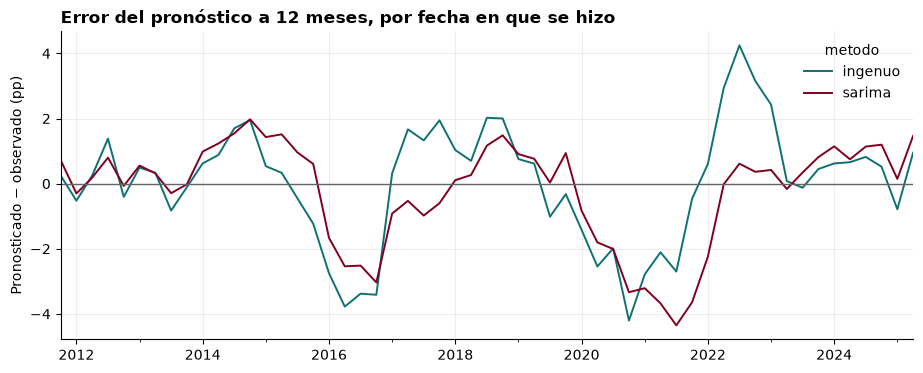

In [12]:
errores = evaluacion.attrs['errores']
doce = errores[errores['horizonte'] == 12].pivot(index='origen', columns='metodo', values='error')

ax = doce.plot(color=[TEAL, GUINDA], lw=1.4)
ax.axhline(0, color=GRIS, lw=1)
ax.set_title('Error del pronóstico a 12 meses, por fecha en que se hizo')
ax.set_ylabel('Pronosticado − observado (pp)'); ax.set_xlabel('')
plt.show()